# Multiple Linear Regression


In [24]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn import metrics

sns.set_style("whitegrid")

In [25]:
df = pd.read_csv("advertising.csv")

print(df.head())

print(df.isnull().sum())

print(df.describe())

print(df.duplicated().sum())

df.info()

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio 

In [26]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print(X.shape)
print(y.shape)

(200, 3)
(200,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)

X train shape: (160, 3)
X test shape: (40, 3)


In [28]:
multiple_regression = LinearRegression()

multiple_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
print(f'b : {multiple_regression.intercept_:.4f}')
print(f'w1 : {multiple_regression.coef_[0]:.4f}')
print(f'w2 : {multiple_regression.coef_[1]:.4f}')
print(f'w3 : {multiple_regression.coef_[2]:.4f}')

b : 4.7141
w1 : 0.0545
w2 : 0.1009
w3 : 0.0043


In [30]:
y_train_predict = multiple_regression.predict(X_train)

y_test_predict = multiple_regression.predict(X_test)

In [31]:
rmse_train = metrics.root_mean_squared_error(y_train, y_train_predict)
print("Train RMSE: ", rmse_train)

rmse_test = metrics.root_mean_squared_error(y_test, y_test_predict)
print("Test RMSE: ", rmse_test)

Train RMSE:  1.635892005537856
Test RMSE:  1.7052146229349223


In [32]:
mae_train = metrics.mean_absolute_error(y_train, y_train_predict)
print("Train MAE: ", mae_train)

mae_test = metrics.mean_absolute_error(y_test, y_test_predict)
print("Test MAE: ", mae_test)

Train MAE:  1.2344160869575869
Test MAE:  1.2748262109549338


In [33]:
r2_train = metrics.r2_score(y_train, y_train_predict)
print("Train R2: ", r2_train)

r2_test = metrics.r2_score(y_test, y_test_predict)
print("Test R2: ", r2_test)

Train R2:  0.9001416005862131
Test R2:  0.9059011844150826


In [34]:
new_sample = pd.DataFrame(
    {'TV': [200.0], 'Radio': [30.0], 'Newspaper': [10.0]})

prediction = multiple_regression.predict(new_sample)
print(f'Prediction for new sample: {prediction[0]:.4f}')

Prediction for new sample: 18.6877


# Logistic Regression Model Train


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [36]:
df = pd.read_csv("womens_clothing_ecommerce_reviews.csv")

print(df.head())

print(df.shape)

                                         Review Text  sentiment
0  Absolutely wonderful - silky and sexy and comf...          1
1  Love this dress!  it's sooo pretty.  i happene...          1
2  I love, love, love this jumpsuit. it's fun, fl...          1
3  This shirt is very flattering to all due to th...          1
4  I love tracy reese dresses, but this one is no...         -1
(19818, 2)


In [37]:
print("Dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:\n", df.duplicated().sum())
print("Empty Review Text:", int(
    (df["Review Text"].fillna("").str.strip() == "").sum()))

# Class imbalance

print("\nClass counts (imbalance matters for accuracy):")
print(df["sentiment"].value_counts())
print("\nClass share")
print(df["sentiment"].value_counts(normalize=True).round(4))
print("\nLabel values:", sorted(df["sentiment"].unique().tolist()))

Dtypes:
 Review Text    object
sentiment       int64
dtype: object

Missing values:
 Review Text    0
sentiment      0
dtype: int64

Duplicate rows:
 7
Empty Review Text: 0

Class counts (imbalance matters for accuracy):
sentiment
 1    17448
-1     2370
Name: count, dtype: int64

Class share
sentiment
 1    0.8804
-1    0.1196
Name: proportion, dtype: float64

Label values: [-1, 1]


Remove duplicates


In [38]:
# Duplicate full rows are not independent observations; drop before the split
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_before - len(df)} duplicate rows. Remaining: {len(df)}")

Dropped 7 duplicate rows. Remaining: 19811


In [39]:
print(df.duplicated().sum())

0


In [40]:
X = df["Review Text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", len(X_train), "| Test size: ", len(X_test))

Train size: 15848 | Test size:  3963


In [41]:
print("\nConverting text to numerical features using Bag-Of-Words...")


# Ignore "a" , "is","the" etc words in the text data
vectorizer = CountVectorizer(stop_words="english")

# Fit the vectorizer on the TRAINING data and transform it into a matrix
X_train_bow = vectorizer.fit_transform(X_train)

print(f"X_train_bow Shape: \n {X_train_bow.shape}")

print(f"Unique words (features): {vectorizer.get_feature_names_out()}")

print(X_train_bow)

# only use transform because we want to use the same features as the training data
X_test_bow = vectorizer.transform(X_test)


Converting text to numerical features using Bag-Of-Words...
X_train_bow Shape: 
 (15848, 11862)
Unique words (features): ['00' '000' '00p' ... 'zooming' 'zuma' 'ã¼ber']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 373248 stored elements and shape (15848, 11862)>
  Coords	Values
  (0, 940)	1
  (0, 8751)	1
  (0, 10636)	1
  (0, 1142)	1
  (0, 9405)	1
  (0, 5853)	1
  (0, 9853)	1
  (0, 2290)	1
  (0, 3346)	1
  (0, 5791)	1
  (0, 4676)	1
  (0, 5286)	1
  (0, 5312)	1
  (0, 7341)	1
  (0, 6038)	2
  (0, 2039)	1
  (0, 9043)	1
  (0, 11213)	1
  (0, 8603)	1
  (0, 6863)	1
  (0, 6175)	1
  (0, 4178)	1
  (0, 7608)	1
  (0, 9475)	2
  (0, 11368)	1
  :	:
  (15846, 1672)	1
  (15847, 9405)	1
  (15847, 11462)	1
  (15847, 1246)	1
  (15847, 11505)	1
  (15847, 8151)	1
  (15847, 2319)	2
  (15847, 3992)	1
  (15847, 4762)	2
  (15847, 8826)	1
  (15847, 5856)	1
  (15847, 7641)	1
  (15847, 9794)	1
  (15847, 5599)	1
  (15847, 6020)	1
  (15847, 5906)	1
  (15847, 3402)	1
  (15847, 572)	1
  (15847, 2913)	2
  (1

In [42]:
# Initialize the model
# max_iter is increased to ensure the model has enough time to find the best weights
# solver: Algorithm for optimization (default: 'lbfgs') Options 'lbfgs','liblinear','saga','newton-cg'
model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

# Train the model on our Bag-of-words training data
model.fit(X_train_bow, y_train)

print("Model Train Complete!")

Model Train Complete!


In [43]:
# Evaluate the model's Performance
# Let's see how accurately our model predicts sentiment on the unseen test data.
print("\nEvaluating model performance on the set...")

y_test_predict = model.predict(X_test_bow)
y_train_predict = model.predict(X_train_bow)

accuracy = accuracy_score(y_train, y_train_predict)
print(f"Model Accuracy (Train): {accuracy:.4f} ({accuracy:.2%})")

accuracy = accuracy_score(y_test, y_test_predict)
print(f"Model Accuracy (Test): {accuracy:.4f} ({accuracy:.2%})")


Evaluating model performance on the set...
Model Accuracy (Train): 0.9784 (97.84%)
Model Accuracy (Test): 0.9281 (92.81%)


Recall , Precision and F1 metrices values

In [44]:
print(classification_report(y_train, y_train_predict))

print("-"*50)

print(classification_report(y_test, y_test_predict))

# macro avg is mean of negative positive 
# weighted avg is mean of weighted negative positive

              precision    recall  f1-score   support

          -1       0.95      0.86      0.91      1895
           1       0.98      0.99      0.99     13953

    accuracy                           0.98     15848
   macro avg       0.97      0.93      0.95     15848
weighted avg       0.98      0.98      0.98     15848

--------------------------------------------------
              precision    recall  f1-score   support

          -1       0.74      0.61      0.67       474
           1       0.95      0.97      0.96      3489

    accuracy                           0.93      3963
   macro avg       0.85      0.79      0.81      3963
weighted avg       0.92      0.93      0.92      3963



Confusion Matrix

In [45]:
print("Confusion Matrix")

print(confusion_matrix(y_test, y_test_predict))

Confusion Matrix
[[ 288  186]
 [  99 3390]]


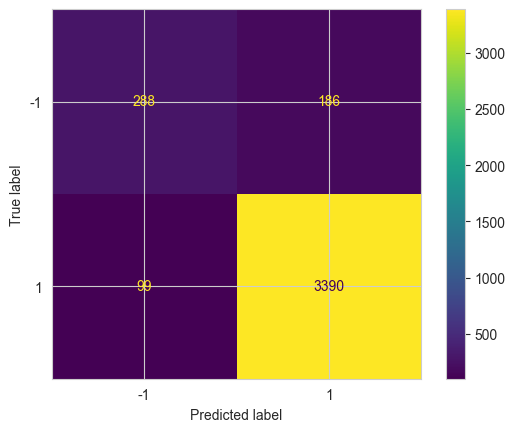

In [51]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_predict)

Get inference

In [55]:
new_reviews = pd.DataFrame({'Review Text': ["Absolutely love this dress! The material is soft and comfortable, and the fit is perfect. The color is exactly as shown in the pictures. Highly recommended!","The design is beautiful, but the fabric was thinner than I expected. The size also felt slightly smaller than the size chart.","Unfortunately, I’m not completely satisfied. The color looks a little different from the photos, and the stitching could be better","Beautiful top and very comfortable to wear. The size was accurate, and it arrived quickly. I’m very happy with my purchase.","Great quality for the price. The stitching is neat, and the fabric feels really nice. I received many compliments when I wore it."]})

new_reviews_bow = vectorizer.transform(new_reviews["Review Text"])

new_reviews_predictions = model.predict(new_reviews_bow)

print("Predictions for new reviews:")

for review, prediction in zip(new_reviews["Review Text"], new_reviews_predictions):
    print(f"Review: {review}\nPredicted Sentiment: {prediction}\n")

print(new_reviews_predictions)



Predictions for new reviews:
Review: Absolutely love this dress! The material is soft and comfortable, and the fit is perfect. The color is exactly as shown in the pictures. Highly recommended!
Predicted Sentiment: 1

Review: The design is beautiful, but the fabric was thinner than I expected. The size also felt slightly smaller than the size chart.
Predicted Sentiment: 1

Review: Unfortunately, I’m not completely satisfied. The color looks a little different from the photos, and the stitching could be better
Predicted Sentiment: -1

Review: Beautiful top and very comfortable to wear. The size was accurate, and it arrived quickly. I’m very happy with my purchase.
Predicted Sentiment: 1

Review: Great quality for the price. The stitching is neat, and the fabric feels really nice. I received many compliments when I wore it.
Predicted Sentiment: 1

[ 1  1 -1  1  1]
